# Demo of Biomarkers

In [1]:
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
from dotenv import load_dotenv
import json
import os

from demo_db import get_db_url

load_dotenv()

ukrdc3_sessionmaker = sessionmaker(
    autocommit=False, autoflush=False, bind=create_engine(get_db_url())
)

ukrdc3 = ukrdc3_sessionmaker()



NameError: name 'contextmanager' is not defined

In [9]:
from ukrdc_stats.calculators.dialysis import DialysisStatsCalculator
from ukrdc_stats.biomarkers import urea_reduction_ratio, cause_of_death, haemoglobin
import datetime as dt


end_time = dt.datetime.today()
start_time = end_time - dt.timedelta(weeks=12)


# get patient list from dialysis stats calculator 
calculator = DialysisStatsCalculator(
    ukrdc3, "RNJ00", from_time=start_time, to_time= end_time
)


"""
calculator = DialysisStatsCalculator(
    ukrdc3, "RJZ", from_time=start_time, to_time= end_time
)
"""

_ = calculator.extract_stats()

# input patient list into 
patient_list = calculator._patient_cohort[
    (calculator._patient_cohort.qbl05 == "HOSP")
    & (calculator._patient_cohort.prevalent == True)
][["ukrdcid", "pid"]]


urr = urea_reduction_ratio(
    start_time,
    end_time,
    patient_list,
    ukrdc3
)

fe = haemoglobin(
    start_time,
    end_time,
    patient_list,
    ukrdc3
)



In [10]:
import plotly.express as px
import pandas as pd 

data = []
for item in urr.patient_data:
    for x,y in zip(item.data.timestamps, item.data.testresult):
        data.append([x,y, item.median_result, item.most_recent_result, item.ukrdcid])


urr_data = pd.DataFrame(data=data, columns=['Date', 'Urea Reduction Ratio', 'Median Patient URR', 'Most Recent Patient URR','ukrdcid'])


fig = px.scatter(urr_data, x = "Date", y = "Urea Reduction Ratio", color= "Median Patient URR", hover_data=["ukrdcid"])
fig.update_traces(marker={'size': 5})
fig.show()



In [11]:
import plotly.express as px
import pandas as pd 

data = []


for item in fe.patient_data:
    for x,y in zip(item.data.timestamps, item.data.testresult):
        data.append([x,y, item.median_result, item.most_recent_result, item.ukrdcid])


urr_data = pd.DataFrame(data=data, columns=['Date', 'Fe', 'Median Fe', 'Most Recent Fe','ukrdcid'])


fig = px.scatter(urr_data, x = "Date", y = "Fe", color= "Median Fe", hover_data=["ukrdcid", 'Most Recent Fe'])
fig.update_traces(marker={'size': 5})
fig.show()

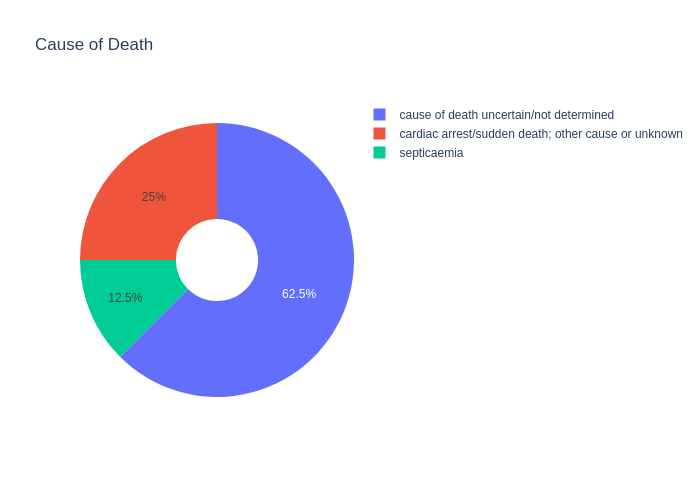

In [12]:
patient_list = calculator._patient_cohort[
    (calculator._patient_cohort.qbl05 == "HOSP")
    & (calculator._patient_cohort.prevalent == False)
][["ukrdcid", "pid"]]

cod = cause_of_death(
    start_time,
    end_time,
    patient_list,
    ukrdc3
)

fig = px.pie(
    values=cod.data.y,
    names=cod.data.x,
    title=cod.metadata.title,
    hole=0.3,
)
fig.show("png")